# 02 - Feature Engineering

## Objectif
- Créer des features décalées (lags)
- Ajouter des features temporelles (heure, jour, saison)
- Gérer les valeurs manquantes
- Normaliser/standardiser les données
- Évaluer l'importance des features

In [1]:
import sys
import os
from pathlib import Path

# Ajout du répertoire parent au path pour les imports source/
_parent = Path(os.getcwd()).parent
if str(_parent) not in sys.path:
    sys.path.insert(0, str(_parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.data.process import preprocess_gh, add_time_features

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Chargement et préparation des données

In [2]:
# Chargement des données
df_serre = pd.read_csv('../datas/serre_u5_climat.csv')
df_meteo = pd.read_csv('../datas/climat_exterieur_2024-06-28_2026-03-17_openmeteo.csv')

# Prétraitement serre : arrondi à l'heure
df_serre = preprocess_gh(df_serre, datetime_col="timestamp", unit="ms")

# Conversion datetime météo
df_meteo['ts'] = pd.to_datetime(df_meteo['time_utc'], utc=True)

# Tri par date
df_serre = df_serre.sort_values('ts').reset_index(drop=True)
df_meteo = df_meteo.sort_values('ts').reset_index(drop=True)

# Fusion des données
df = pd.merge_asof(df_serre, df_meteo, on='ts', direction='nearest', tolerance=pd.Timedelta('1h'))

print(f"Données fusionnées: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")
print(f"\nExemple timestamp arrondi:")
print(df_serre[["timestamp", "ts"]].head(3))

Données fusionnées: (37975, 20)
Colonnes: ['timestamp', 'fecha', 'hora', 'tempint', 'humedadint', 'dispositivo', 'ts', 'time_utc', 'cloud_cover', 'dew_point_2m', 'precipitation', 'pressure_msl', 'rain', 'relative_humidity_2m', 'shortwave_radiation', 'snowfall', 'temperature_2m', 'wind_direction_10m', 'wind_gusts_10m', 'wind_speed_10m']

Exemple timestamp arrondi:
            timestamp                        ts
0 2024-06-28 11:00:00 2024-06-28 11:00:00+00:00
1 2024-06-28 12:00:00 2024-06-28 12:00:00+00:00
2 2024-06-28 12:00:00 2024-06-28 12:00:00+00:00


In [3]:
print(df.isnull().sum())

timestamp               0
fecha                   0
hora                    0
tempint                 0
humedadint              0
dispositivo             0
ts                      0
time_utc                0
cloud_cover             0
dew_point_2m            0
precipitation           0
pressure_msl            0
rain                    0
relative_humidity_2m    0
shortwave_radiation     0
snowfall                0
temperature_2m          0
wind_direction_10m      0
wind_gusts_10m          0
wind_speed_10m          0
dtype: int64


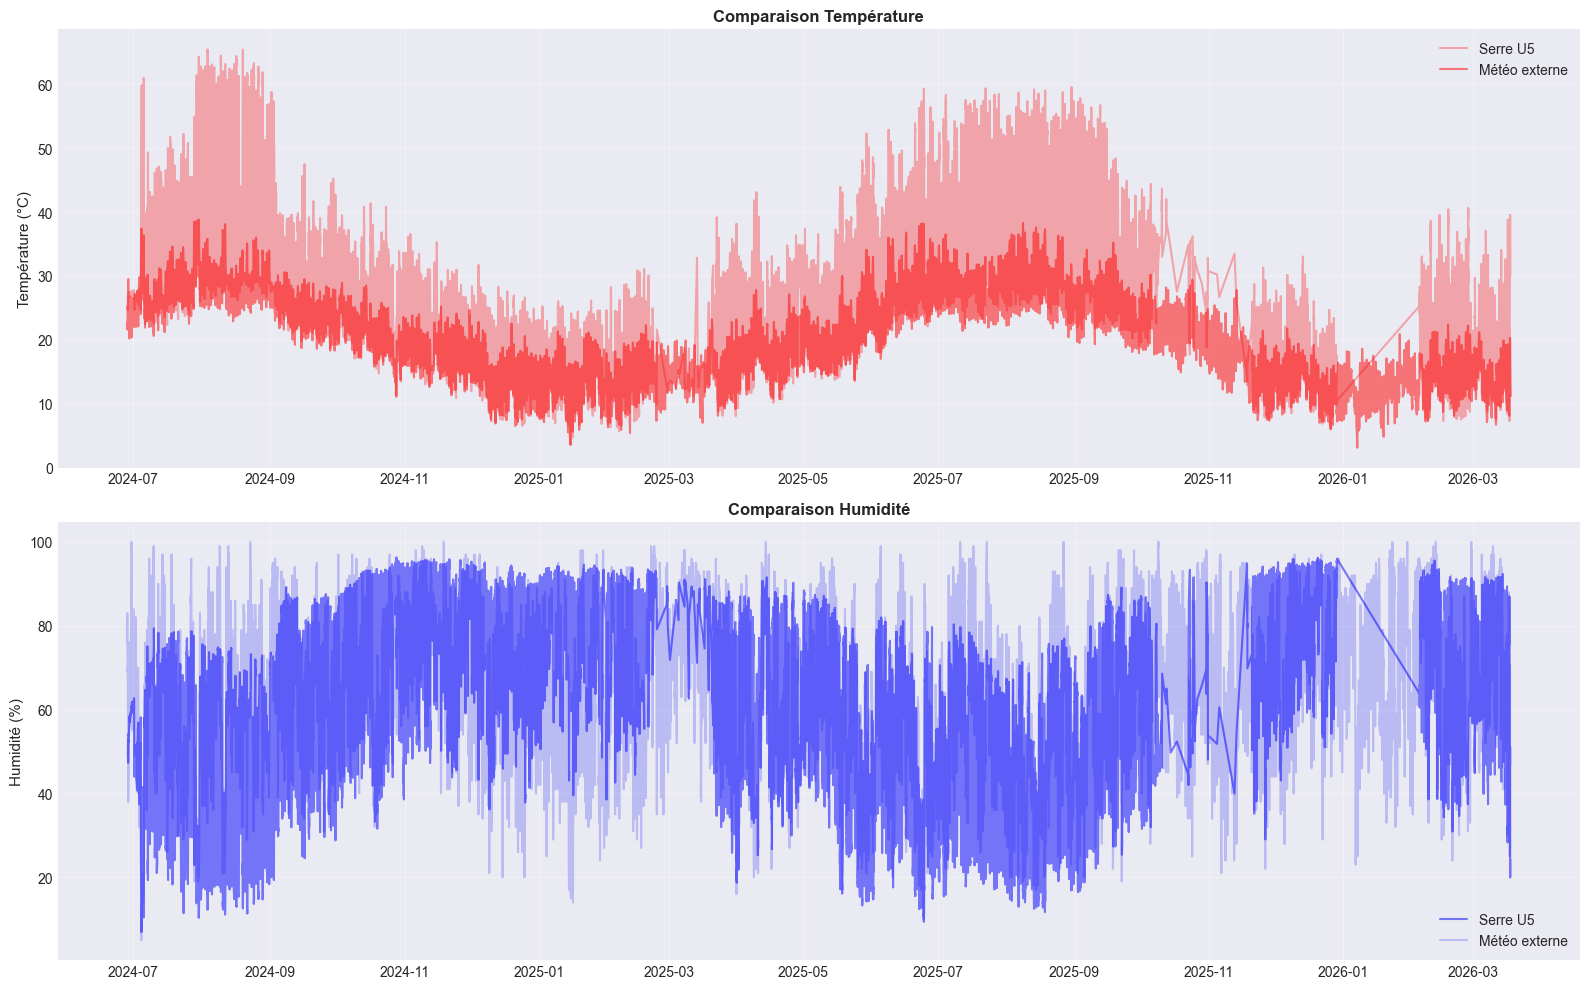

In [4]:
import sys
import os
from pathlib import Path

# Le notebook est dans online ML test lina/notebooks/
# On remonte d'un niveau pour accéder au répertoire online ML test lina
notebook_dir = Path(os.getcwd())
parent_dir = notebook_dir.parent

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from src.vizu.plots import plot_serre_vs_meteo

# Afficher la comparaison
fig = plot_serre_vs_meteo(df_serre, df_meteo)
plt.show()

## 2. Traitement des valeurs manquantes

In [5]:
# Pour l'instant NON
# print("Valeurs manquantes avant traitement:")
# print(df.isnull().sum())

# # Stratégie: interpolation linéaire pour les séries temporelles
# numeric_cols = df.select_dtypes(include=[np.number]).columns

# for col in numeric_cols:
#     if df[col].isnull().sum() > 0:
#         # Forward fill suivi de backward fill
#         df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
#         # Interpolation linéaire
#         df[col] = df[col].interpolate(method='linear')

# print("\nValeurs manquantes après traitement:")
# print(df.isnull().sum())

## 3. Features temporelles

In [6]:
df = add_time_features(df, datetime_col="ts")

print("Features temporelles créées:")
print(df[['ts', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos']].head(10))

Features temporelles créées:
                         ts  hour  day_of_week  month      hour_sin  hour_cos
0 2024-06-28 11:00:00+00:00    11            4      6  2.588190e-01 -0.965926
1 2024-06-28 12:00:00+00:00    12            4      6  1.224647e-16 -1.000000
2 2024-06-28 12:00:00+00:00    12            4      6  1.224647e-16 -1.000000
3 2024-06-28 12:00:00+00:00    12            4      6  1.224647e-16 -1.000000
4 2024-06-28 13:00:00+00:00    13            4      6 -2.588190e-01 -0.965926
5 2024-06-28 13:00:00+00:00    13            4      6 -2.588190e-01 -0.965926
6 2024-06-28 13:00:00+00:00    13            4      6 -2.588190e-01 -0.965926
7 2024-06-28 13:00:00+00:00    13            4      6 -2.588190e-01 -0.965926
8 2024-06-28 14:00:00+00:00    14            4      6 -5.000000e-01 -0.866025
9 2024-06-28 14:00:00+00:00    14            4      6 -5.000000e-01 -0.866025


## 4. Features décalées (Lags)

In [7]:
from src.data.process import create_lag_features

target_cols = ['tempint', 'humedadint']
lag_hours = [1, 2, 3, 6, 12, 24, 48]

df = create_lag_features(df, target_cols=target_cols, lags=lag_hours)

print(f"Lags créés pour {len(target_cols)} colonnes")
print(f"Lags: {lag_hours}")
print(f"\nNombres de colonnes après lags: {df.shape[1]}")

Lags créés pour 2 colonnes
Lags: [1, 2, 3, 6, 12, 24, 48]

Nombres de colonnes après lags: 45


## 5. Rolling feat

In [8]:
from src.data.process import RollingFeatures

roller = RollingFeatures(cols=['tempint', 'humedadint'], windows=[6, 24])
df = roller.fit_transform(df)

## 5. Features météorologiques externes

In [9]:
# # Ajouter des features dérivées de la météo externe
# temp_cols = [c for c in df.columns if 'temperature' in c.lower() or ('temp' in c.lower() and c != 'tempint')]
# humidity_cols = [c for c in df.columns if 'humidity' in c.lower() or 'humid' in c.lower()]

# print(f"Colonnes température externe: {temp_cols}")
# print(f"Colonnes humidité externe: {humidity_cols}")

# # Ajouter des features dérivées
# if len(temp_cols) > 0:
#     df['temp_ext_lag_1h'] = df[temp_cols[0]].shift(1)
#     df['temp_ext_lag_6h'] = df[temp_cols[0]].shift(6)
#     df['temp_ext_lag_24h'] = df[temp_cols[0]].shift(24)

# if len(humidity_cols) > 0:
#     df['humidity_ext_lag_1h'] = df[humidity_cols[0]].shift(1)
#     df['humidity_ext_lag_6h'] = df[humidity_cols[0]].shift(6)
#     df['humidity_ext_lag_24h'] = df[humidity_cols[0]].shift(24)

# print("\nFeatures externes avec lags créées.")

## 6. Features d'interaction

Créer quelques features d'interaction pertinentes

In [10]:
# # Écarts de température et humidité (serre vs externe)
# if 'tempint' in df.columns and len(temp_cols) > 0:
#     df['temp_diff'] = df['tempint'] - df[temp_cols[0]]
#     df['temp_diff_lag_1h'] = df['temp_diff'].shift(1)

# if 'humedadint' in df.columns and len(humidity_cols) > 0:
#     df['humidity_diff'] = df['humedadint'] - df[humidity_cols[0]]
#     df['humidity_diff_lag_1h'] = df['humidity_diff'].shift(1)

## 7. Nettoyage des données (suppression des NaN)

In [11]:
# # Supprimer les lignes avec des NaN (causées par les lags et rolling windows)
df_clean = df.copy()

# print(f"Forme originale: {df.shape}")
# print(f"Forme après suppression des NaN: {df_clean.shape}")
# print(f"Lignes supprimées: {df.shape[0] - df_clean.shape[0]}")

# # Vérification
# print(f"\nValeurs manquantes restantes: {df_clean.isnull().sum().sum()}")

# + outlier

## 8. Normalisation des données

In [12]:
from src.data.process import Normalizer
normalizer = Normalizer(save_path='../src/data/scaler.pkl')

# fit uniquement sur le train, transform sur tout pour l'instant
df_normalized = normalizer.fit_transform(df_clean)

print("Données normalisées (StandardScaler)")
print(df_normalized[normalizer.numeric_cols].describe())

Données normalisées (StandardScaler)
              fecha       tempint    humedadint  dispositivo   cloud_cover  \
count  3.797500e+04  3.797500e+04  3.797500e+04      37975.0  3.797500e+04   
mean   7.184948e-15 -4.789966e-17 -1.556739e-16          0.0 -7.184948e-17   
std    1.000013e+00  1.000013e+00  1.000013e+00          0.0  1.000013e+00   
min   -1.582806e+00 -1.795672e+00 -2.543568e+00          0.0 -8.382955e-01   
25%   -8.965239e-01 -8.060069e-01 -7.376461e-01          0.0 -8.382955e-01   
50%    2.967780e-02 -1.093899e-01  1.653148e-01          0.0 -5.557402e-01   
75%    7.326984e-01  4.792179e-01  9.185870e-01          0.0  9.340968e-01   
max    1.915558e+00  3.379556e+00  1.380822e+00          0.0  1.730389e+00   

       dew_point_2m  precipitation  pressure_msl          rain  \
count  3.797500e+04   3.797500e+04  3.797500e+04  3.797500e+04   
mean  -1.317241e-16   2.993728e-18  3.194308e-14  2.993728e-18   
std    1.000013e+00   1.000013e+00  1.000013e+00  1.000013e+00

## 9. Visualisation de l'importance des features

Analyser la corrélation avec la cible (température)

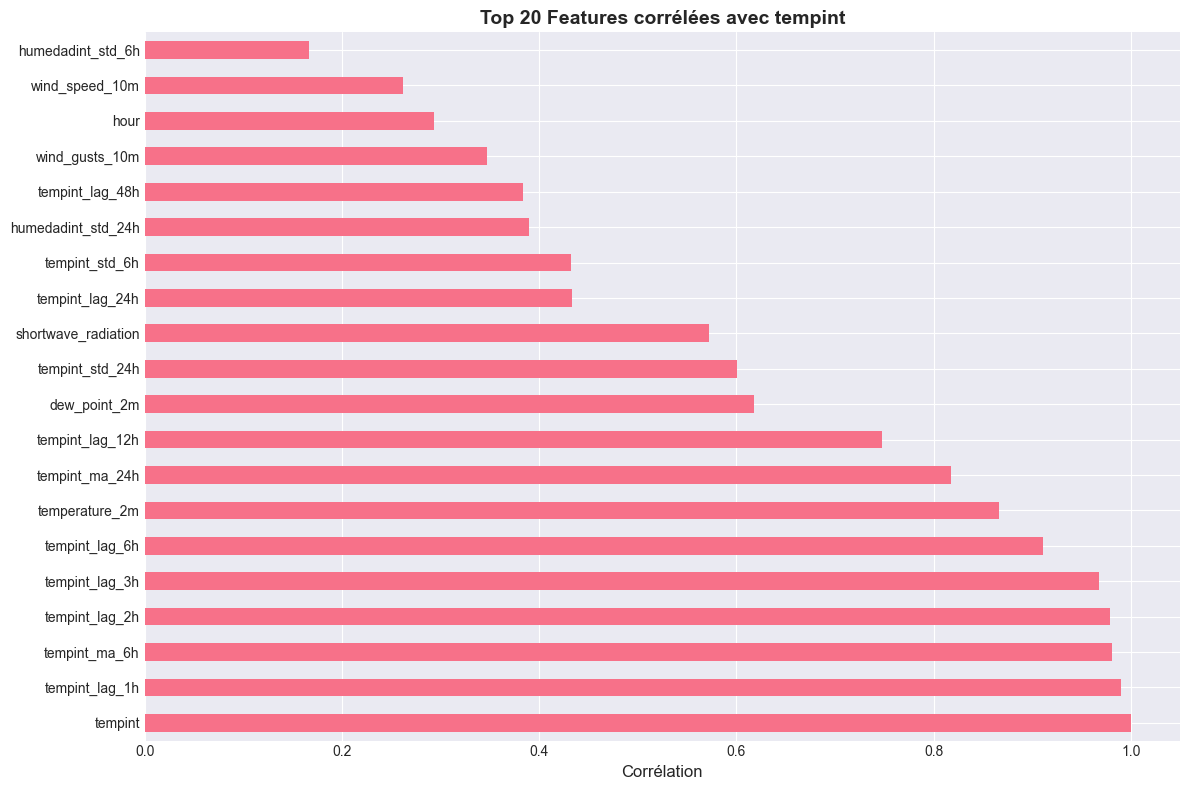

Top 10 features positives:
tempint            1.000000
tempint_lag_1h     0.990075
tempint_ma_6h      0.981202
tempint_lag_2h     0.979037
tempint_lag_3h     0.967837
tempint_lag_6h     0.911411
temperature_2m     0.865970
tempint_ma_24h     0.817387
tempint_lag_12h    0.747653
dew_point_2m       0.618260
Name: tempint, dtype: float64

Top 10 features négatives:
tempint_std_24h        0.600829
shortwave_radiation    0.572404
tempint_lag_24h        0.433182
tempint_std_6h         0.432732
humedadint_std_24h     0.389331
tempint_lag_48h        0.383624
wind_gusts_10m         0.347561
hour                   0.293003
wind_speed_10m         0.261453
humedadint_std_6h      0.167022
Name: tempint, dtype: float64


In [13]:
# Corrélation avec la température cible (tempint)
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if 'tempint' in df_clean.columns:
    target = 'tempint'
    correlations = df_clean[numeric_features].corr()[target].sort_values(ascending=False)
    
    # Top 20 features
    top_features = correlations.head(20)
    
    plt.figure(figsize=(12, 8))
    top_features.plot(kind='barh')
    plt.xlabel('Corrélation', fontsize=12)
    plt.title(f'Top 20 Features corrélées avec {target}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 features positives:")
    print(top_features.head(10))
    print("\nTop 10 features négatives:")
    print(top_features.tail(10))

Corrélation avec humidité

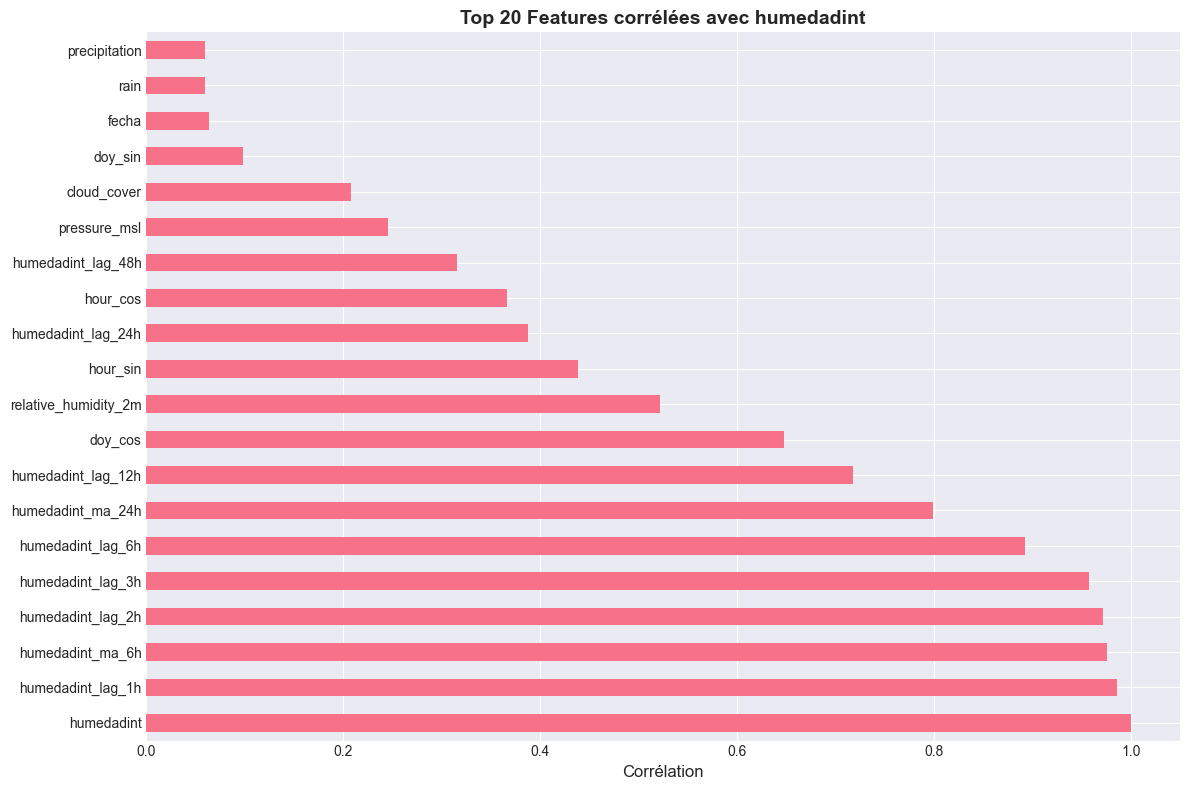

Top 10 features positives:
humedadint              1.000000
humedadint_lag_1h       0.985534
humedadint_ma_6h        0.976086
humedadint_lag_2h       0.971441
humedadint_lag_3h       0.957828
humedadint_lag_6h       0.892807
humedadint_ma_24h       0.798709
humedadint_lag_12h      0.718119
doy_cos                 0.648142
relative_humidity_2m    0.521294
Name: humedadint, dtype: float64

Top 10 features négatives:
hour_sin              0.438628
humedadint_lag_24h    0.387655
hour_cos              0.366630
humedadint_lag_48h    0.315198
pressure_msl          0.245464
cloud_cover           0.207494
doy_sin               0.098325
fecha                 0.063902
rain                  0.059525
precipitation         0.059525
Name: humedadint, dtype: float64


In [14]:
# Corrélation avec l'humidité cible (humedadint)
if 'humedadint' in df_clean.columns:
    target = 'humedadint'
    correlations = df_clean[numeric_features].corr()[target].sort_values(ascending=False)
    
    # Top 20 features
    top_features = correlations.head(20)
    
    plt.figure(figsize=(12, 8))
    top_features.plot(kind='barh')
    plt.xlabel('Corrélation', fontsize=12)
    plt.title(f'Top 20 Features corrélées avec {target}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 features positives:")
    print(top_features.head(10))
    print("\nTop 10 features négatives:")
    print(top_features.tail(10))

## 10. Sauvegarde des données préparées

Exporter les données pour les étapes suivantes

In [ ]:
# Sauvegarder les données brutes et normalisées
# df_clean.to_csv('../datas/df_features.csv', index=False)
# df_normalized.to_csv('../datas/df_normalized.csv', index=False)

print("Données sauvegardées:")
print("  - ../datas/df_features.csv")
print("  - ../datas/df_normalized.csv")
print(f"  - ../source/data/scaler.pkl")

# Résumé des features
print(f"\n=" * 2)
print(f"RÉSUMÉ - Feature Engineering")
print(f"=" * 2)
print(f"Nombre de features créées: {len(numeric_features)}")
print(f"Nombre d'observations: {len(df_clean):,}")
print(f"Plage temporelle: {df_clean['ts'].min()} à {df_clean['ts'].max()}")
print(f"\nTypes de features:")
print(f"  - Temporelles: hour, day_of_week, month, ..., hour_sin/cos, etc.")
print(f"  - Décalées (lags): {lag_hours}")
print(f"  - Interaction: temp_diff, humidity_diff, ...")
print(f"  - Agrégation: moyennes mobiles, écart-type mobile")

Données sauvegardées:
  - ../datas/df_features.csv
  - ../datas/df_normalized.csv
  - ../source/data/scaler.pkl

=
=
RÉSUMÉ - Feature Engineering
==
Nombre de features créées: 49
Nombre d'observations: 37,975
Plage temporelle: 2024-06-28 11:00:00+00:00 à 2026-03-17 18:00:00+00:00

Types de features:
  - Temporelles: hour, day_of_week, month, ..., hour_sin/cos, etc.
  - Décalées (lags): [1, 2, 3, 6, 12, 24, 48]
  - Interaction: temp_diff, humidity_diff, ...
  - Agrégation: moyennes mobiles, écart-type mobile
